# Prueba real con audio creado por los integrantes

1. El audio se toma a partir de la carpeta 'data/raw/voz.wav'.
2. Se le inyecta un pitido de 800Hz
3. Como creamos un "nuevo" audio, se guarda para lograr un antes y un despues.
4. Se limpia mediante la transformada de Fourier. De igual forma, al tener la señal limpia, se guarda.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import soundfile as sf
from scipy.fft import fft, ifft

# 1. Importamos tus módulos
sys.path.append("..")
from src.audio_loader import load_audio
from src.filters import apply_notch_mask

# 2. Cargar tu voz real
RUTA_VOZ = Path("../data/raw/voz.wav")
senal_ideal, sample_rate = load_audio(RUTA_VOZ)

# 3. SInyectar ruido
t = np.arange(len(senal_ideal)) / sample_rate
pitido_molesto = 0.5 * np.sin(2 * np.pi * 800 * t)
senal_arruinada = senal_ideal + pitido_molesto

# Guardamos el audio arruinado para la presentación
sf.write("../data/processed/voz_arruinada.wav", senal_arruinada, sample_rate)

# 4. RESCATE: Limpiamos con la Transformada de Fourier
espectro_arruinado = fft(senal_arruinada)
# Aplicamos la máscara específicamente en 800 Hz
espectro_limpio = apply_notch_mask(espectro_arruinado, center_hz=800.0, bandwidth_hz=10.0, sample_rate=sample_rate)
# Reconstrucción
senal_rescatada = np.real(ifft(espectro_limpio))

# Guardamos el audio rescatado
sf.write("../data/processed/voz_rescatada.wav", senal_rescatada, sample_rate)

print("¡Audio arruinado y rescatado con éxito!")
print("Revisa la carpeta 'data/processed/' para escuchar el resultado.")

¡Audio arruinado y rescatado con éxito!
Revisa la carpeta 'data/processed/' para escuchar el resultado.


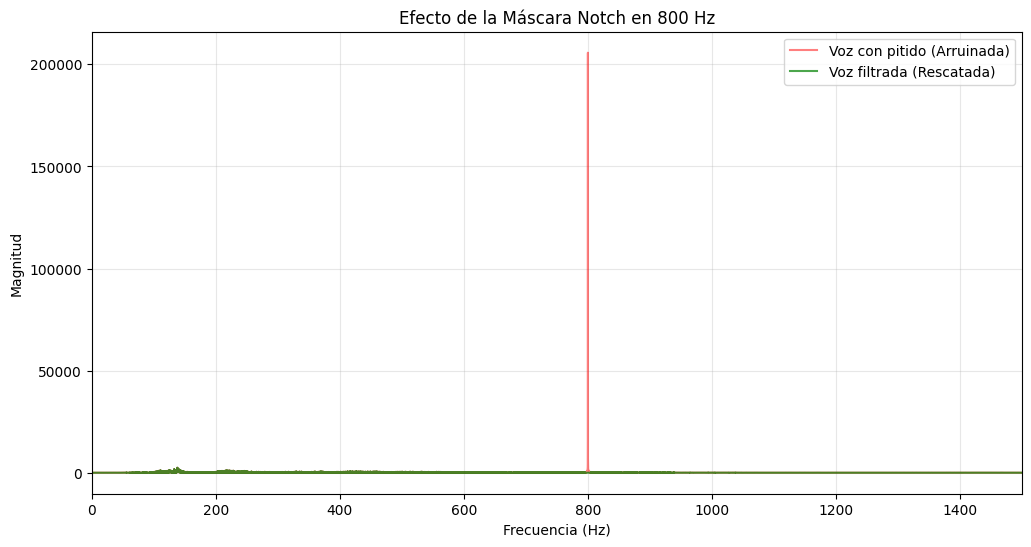

In [ ]:
import matplotlib.pyplot as plt
from scipy.fft import fftfreq

# Preparamos los datos para graficar
N = len(senal_arruinada)
frecuencias = fftfreq(N, 1 / sample_rate)
mitad = N // 2

# Magnitudes
mag_arruinada = np.abs(fft(senal_arruinada)[:mitad])
mag_rescatada = np.abs(fft(senal_rescatada)[:mitad])

plt.figure(figsize=(12, 6))
plt.plot(frecuencias[:mitad], mag_arruinada, color='red', alpha=0.5, label='Voz con pitido (Arruinada)')
plt.plot(frecuencias[:mitad], mag_rescatada, color='green', alpha=0.7, label='Voz filtrada (Rescatada)')

plt.title("Efecto de la Máscara Notch en 800 Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 1500)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Prueba arcaica, lo mas basica posible, para generar las transformadas de fourier paso a paso

In [1]:
import cmath
import math
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

# --- 1. LAS MATEMÁTICAS ARCAICAS (A MANO) ---

def dft_primitiva(x):
    """Transformada Discreta de Fourier paso a paso (Viaje a la frecuencia)"""
    N = len(x)
    X = []
    for k in range(N):
        suma = 0j
        for n in range(N):
            angulo = -2j * cmath.pi * k * n / N
            suma += x[n] * cmath.exp(angulo)
        X.append(suma)
    return X

def idft_primitiva(X):
    """Transformada INVERSA Discreta de Fourier paso a paso (Viaje al tiempo)"""
    N = len(X)
    x_reconstruido = []
    for n in range(N):
        suma = 0j
        for k in range(N):
            angulo = 2j * cmath.pi * k * n / N  # ¡Ángulo positivo!
            suma += X[k] * cmath.exp(angulo)
        # Dividimos entre N y tomamos la parte real (el audio físico no tiene números imaginarios)
        x_reconstruido.append((suma / N).real)
    return x_reconstruido

# --- 2. EL EXPERIMENTO CON MICRO-AUDIO ---

# Configuramos un audio minúsculo (0.5 segundos a 2000 Hz = Solo 1000 números)
sample_rate = 2000
duration = 0.5
N = int(sample_rate * duration)
t = np.arange(N) / sample_rate

print(f"Iniciando procesamiento de {N} muestras...")
print("Esto tomará unos 2 a 5 segundos (¡Imagina si fueran 100,000 muestras!)...")

# Creamos una nota pura (440 Hz) y le inyectamos un zumbido súper grave (100 Hz)
senal_pura = 0.5 * np.sin(2 * np.pi * 440 * t)
ruido_grave = 0.5 * np.sin(2 * np.pi * 100 * t)
micro_audio_ruidoso = senal_pura + ruido_grave

# Guardamos el audio con ruido para la comparación
sf.write("../data/processed/arcaico_ruidoso.wav", micro_audio_ruidoso, sample_rate)

# --- 3. APLICANDO EL CICLO ---

# PASO A: Convertimos a frecuencias (Tardará un poquito)
espectro = dft_primitiva(micro_audio_ruidoso)

# PASO B: Aplicamos una Máscara Primitiva para borrar los 100 Hz
# (A 2000 Hz de sample rate, los 100 Hz caen exactamente en el índice k=25 y k=975)
espectro[25] = 0j
espectro[975] = 0j

# PASO C: Reconstruimos el audio usando nuestra Inversa Arcaica
micro_audio_limpio = idft_primitiva(espectro)

# Guardamos el resultado limpio
sf.write("../data/processed/arcaico_limpio.wav", micro_audio_limpio, sample_rate)

print("¡Proceso completado con éxito!")
print("Revisa los archivos 'arcaico_ruidoso.wav' y 'arcaico_limpio.wav'")

Iniciando procesamiento de 1000 muestras...
Esto tomará unos 2 a 5 segundos (¡Imagina si fueran 100,000 muestras!)...
¡Proceso completado con éxito!
Revisa los archivos 'arcaico_ruidoso.wav' y 'arcaico_limpio.wav'


Realmente, no es muy descriptiva esta prueba, porque solamente son 0.5 segundos, no nos brinda un ejemplo muy claro. Asi que, creo, que es mejor deshecharlos